In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

In [5]:
train_df = pd.read_parquet("/Users/sudhanvabharadwaj/Documents/Full_Quant_Pipeline/Data/processed/train_normalized_df.parquet")

rank_cols = [col for col in train_df.columns if '_rank' in col]
train_df = train_df.drop(columns=rank_cols)

test_df = pd.read_parquet("/Users/sudhanvabharadwaj/Documents/Full_Quant_Pipeline/Data/processed/test_normalized_df.parquet")

rank_cols = [col for col in test_df.columns if '_rank' in col]
test_df = test_df.drop(columns=rank_cols)

val_df = pd.read_parquet("/Users/sudhanvabharadwaj/Documents/Full_Quant_Pipeline/Data/processed/val_normalized_df.parquet")

rank_cols = [col for col in val_df.columns if '_rank' in col]
val_df = val_df.drop(columns=rank_cols)

In [6]:
feature_cols = [
    c for c in train_df.columns
    if c not in ["date","ticker", "fwd_return_5d"]
]

In [39]:
x_train = train_df[feature_cols]
y_train = train_df["fwd_return_5d"]

x_val = val_df[feature_cols]
y_val = val_df["fwd_return_5d"]

x_test = test_df[feature_cols]
y_test = test_df["fwd_return_5d"]

In [8]:
train_df.shape

(109284, 37)

-------

Important point before moving to the models:

Here we use the IC between the predicted value and the target variable as the metric to judge how good the model is. 

We do not use MSE, MSME, Accuracy, R^2

Model 1: Linear Baseline

--------

In [ ]:
lr_model = LinearRegression()

lr_model.fit(x_train, y_train)

y_pred = lr_model.predict(x_val)

In [ ]:
print("Validation R2:", r2_score(y_val, y_pred))

print(lr_model.coef_)    
print(lr_model.intercept_) 

Validation R2: -0.007128494235532079
[ 3.66860165e-04 -2.90777687e-04 -7.48878490e-04  1.92788738e-04
 -1.50248280e-04  2.89982314e-04  1.64387189e-04 -4.60945239e-05
 -2.63736567e-04 -6.19613128e-04  7.09513500e-04  5.57429895e-04
  1.07946170e-04 -4.69944777e-04  1.00066374e-04  5.68591873e-04
 -3.30226298e-05 -1.26483013e-03  3.04919631e-04  8.84235540e-06
  2.50096470e-03  7.87927516e-04  8.61952250e-04  6.46594525e-04
 -7.09167301e-04 -2.73579472e-04  1.60656850e-03 -6.56311130e-03
  5.57564517e-03 -8.77550499e-04 -2.39921272e-04  4.11370478e-04
  5.92605370e-04  2.06023442e-04]
0.004443532746907063


In [12]:
# Evaluating Alpha with IC

from scipy.stats import spearmanr

def daily_ic(df):
    
    ic_vals = []

    for d, grp in df.groupby("date"):
        
        if grp["alpha_score"].std() == 0:
            continue
            
        ic = spearmanr(grp["alpha_score"], grp["fwd_return_5d"])[0]
        ic_vals.append(ic)

    return np.array(ic_vals)

In [13]:
# Train IC:

predict_val = lr_model.predict(x_train)
print("Validation R2:", r2_score(y_train, predict_val))

train_df["alpha_score"] = predict_val

ic_vals = daily_ic(train_df)

print("Mean IC:", np.mean(ic_vals))
print("IC IR:", np.mean(ic_vals) / np.std(ic_vals))

Validation R2: 0.004373824120314618
Mean IC: 0.04375819052533671
IC IR: 0.1726310920286778


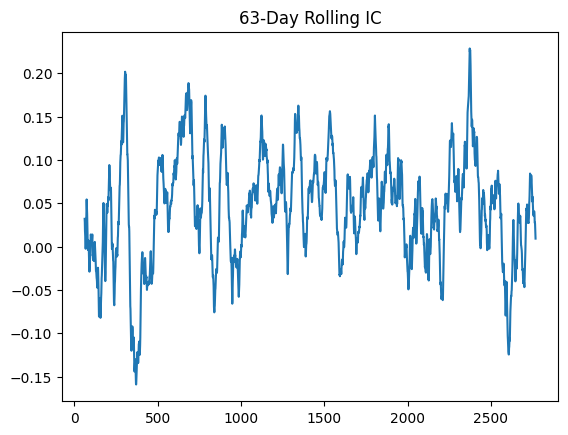

In [14]:
import matplotlib.pyplot as plt

plt.plot(pd.Series(ic_vals).rolling(63).mean())
plt.title("63-Day Rolling IC")
plt.show()

In [16]:
val = val_df.copy()

val["alpha_score"] = y_pred

In [17]:
ic_vals = daily_ic(val)

print("Mean IC:", np.mean(ic_vals))
print("IC IR:", np.mean(ic_vals) / np.std(ic_vals))

Mean IC: -0.001083677298311443
IC IR: -0.0036180125660029896


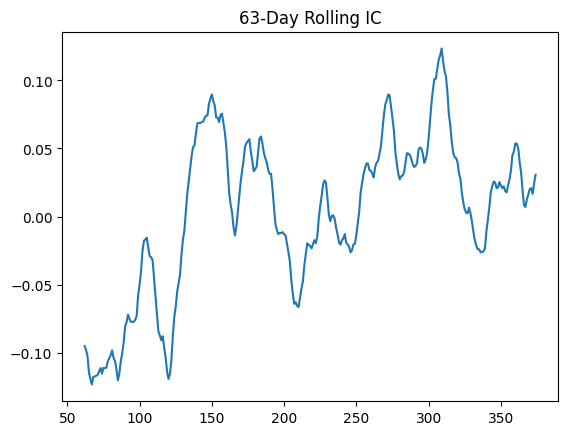

In [18]:
import matplotlib.pyplot as plt

plt.plot(pd.Series(ic_vals).rolling(63).mean())
plt.title("63-Day Rolling IC")
plt.show()

------

Model 2: Ridge

------

In [19]:
ridge = Ridge(alpha = 1.0)

ridge.fit(x_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [20]:
predict_val = ridge.predict(x_val)
print("Validation R2:", r2_score(y_val, predict_val))

Validation R2: -0.0071272994306372794


In [21]:
val = val_df.copy()

val["alpha_score"] = predict_val

In [22]:
ic_vals = daily_ic(val)

print("Mean IC:", np.mean(ic_vals))
print("IC IR:", np.mean(ic_vals) / np.std(ic_vals))

Mean IC: -0.0010611632270168864
IC IR: -0.003543060099169141


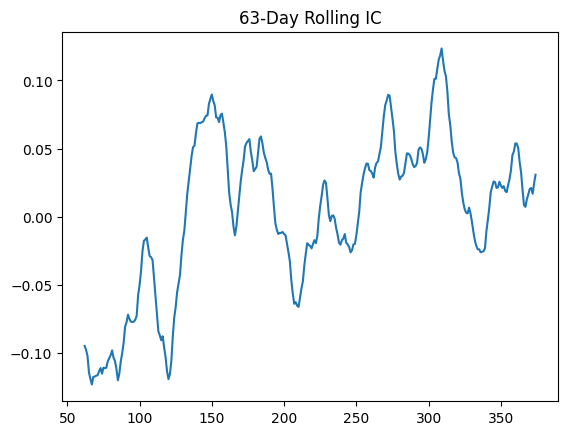

In [23]:
import matplotlib.pyplot as plt

plt.plot(pd.Series(ic_vals).rolling(63).mean())
plt.title("63-Day Rolling IC")
plt.show()

In [24]:
ridge.coef_

array([ 3.66844285e-04, -2.90844121e-04, -7.48687144e-04,  1.92770311e-04,
       -1.50338409e-04,  2.89972980e-04,  1.64344464e-04, -4.60800293e-05,
       -2.63647609e-04, -6.19562338e-04,  7.09349355e-04,  5.57478629e-04,
        1.07967072e-04, -4.69845123e-04,  9.99975613e-05,  5.68537438e-04,
       -3.28912180e-05, -1.26432350e-03,  3.04921266e-04,  8.33847184e-06,
        2.50100093e-03,  7.87663608e-04,  8.61756234e-04,  6.46603230e-04,
       -7.09086828e-04, -2.73617770e-04,  1.60367048e-03, -6.55325120e-03,
        5.56864342e-03, -8.77498184e-04, -2.39709015e-04,  4.11422382e-04,
        5.92507245e-04,  2.06089109e-04])

IC is very unstable and value is not significant (good avg. value would be 0.3 to 0.5)

This makes sense: Selected features weren't great, model cannot learn non-linear features

We can clearly see how all metrics collapse (model is underfitting)

Experimenting with hyperparameters:



In [25]:
ridge2 = Ridge(alpha = 0.01)

ridge2.fit(x_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [26]:
ridge3 = Ridge(alpha = 1000)

ridge3.fit(x_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1000
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


Validation R2: -0.007128482268769387
Mean IC: -0.0010881801125703513
IC IR: -0.0036330177136026185


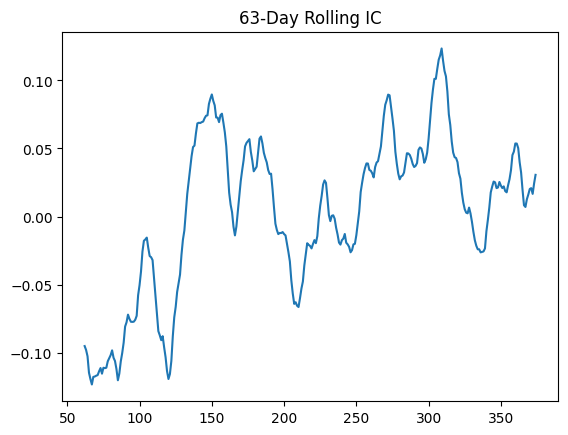

In [27]:
predict_val = ridge2.predict(x_val)
print("Validation R2:", r2_score(y_val, predict_val))

val = val_df.copy()

val["alpha_score"] = predict_val

ic_vals = daily_ic(val)

print("Mean IC:", np.mean(ic_vals))
print("IC IR:", np.mean(ic_vals) / np.std(ic_vals))

plt.plot(pd.Series(ic_vals).rolling(63).mean())
plt.title("63-Day Rolling IC")
plt.show()

In [28]:
ridge2.coef_

array([ 3.66860006e-04, -2.90778352e-04, -7.48876576e-04,  1.92788554e-04,
       -1.50249183e-04,  2.89982220e-04,  1.64386761e-04, -4.60943787e-05,
       -2.63735676e-04, -6.19612620e-04,  7.09511858e-04,  5.57430383e-04,
        1.07946379e-04, -4.69943780e-04,  1.00065685e-04,  5.68591328e-04,
       -3.30213147e-05, -1.26482506e-03,  3.04919648e-04,  8.83730433e-06,
        2.50096507e-03,  7.87924877e-04,  8.61950289e-04,  6.46594613e-04,
       -7.09166496e-04, -2.73579856e-04,  1.60653948e-03, -6.56301256e-03,
        5.57557505e-03, -8.77549975e-04, -2.39919146e-04,  4.11370998e-04,
        5.92604387e-04,  2.06024099e-04])

Validation R2: -0.006660961139080657
Mean IC: -0.0022028767979987503
IC IR: -0.007095063824303216


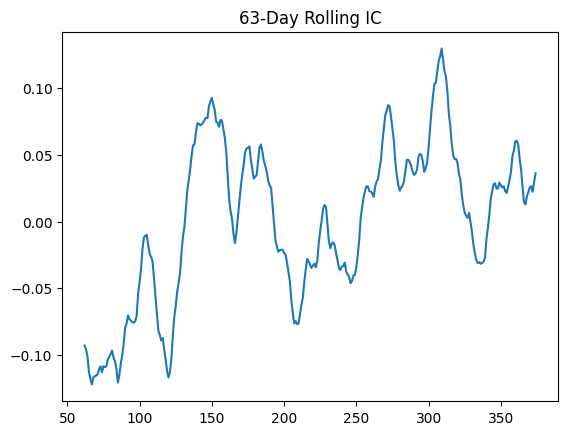

In [29]:
predict_val = ridge3.predict(x_val)
print("Validation R2:", r2_score(y_val, predict_val))

val = val_df.copy()

val["alpha_score"] = predict_val

ic_vals = daily_ic(val)

print("Mean IC:", np.mean(ic_vals))
print("IC IR:", np.mean(ic_vals) / np.std(ic_vals))

plt.plot(pd.Series(ic_vals).rolling(63).mean())
plt.title("63-Day Rolling IC")
plt.show()

Trying to find optimal alpha value

In [30]:
alphas = [1e-3, 1e-2, 1e-1, 1, 10, 100, 1000, 10000]
best_ic = -np.inf
best_alpha = None

for a in alphas:
    model = Ridge(alpha=a)
    model.fit(x_train, y_train)
    preds = model.predict(x_val)
    ic = spearmanr(preds, y_val).correlation  # cross-sectional IC
    if ic > best_ic:
        best_ic = ic
        best_alpha = a

In [31]:
best_alpha

0.001

Alpha is really big -> Very heavy regularization required. 
This tracks since multicollieanrity is present, dataset is noisy

-----

Ridge barely outperforms OLS in terms of validation IC:

1. Low-signal features
Features have weak predictive power for 5-day returns.
Shrinking coefficients, which Ridge does cannot help because there’s not much to stabilize

2. Multicollinearity 
Ridge mainly deals with multicollinearity
Theres not a big case of MC, so Ridge won’t make a big difference.

3. Dataset is small and noisy
Small improvements from Ridge may not appear clearly in IC.

-----

Portfolio Construction, Backtesting

------

In [32]:
import portfolio_cons_backtest
import importlib

importlib.reload(portfolio_cons_backtest)

<module 'portfolio_cons_backtest' from '/Users/sudhanvabharadwaj/Documents/Full_Quant_Pipeline/src/portfolio_cons_backtest.py'>

In [33]:
from portfolio_cons_backtest import *

In [35]:
val1 = val_df.copy()

val1['pred'] = lr_model.predict(x_val)

------

1. Baseline LR

------

Position sum check (should be ~0): 0.000000


/Users/sudhanvabharadwaj/Documents/Full_Quant_Pipeline/src/portfolio_cons_backtest.py:34: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.11111111 0.11111111 0.11111111 ... 0.11111111 0.11111111 0.11111111]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['position'] == 1, 'position'] = 1.0 / n_long[df['position'] == 1]


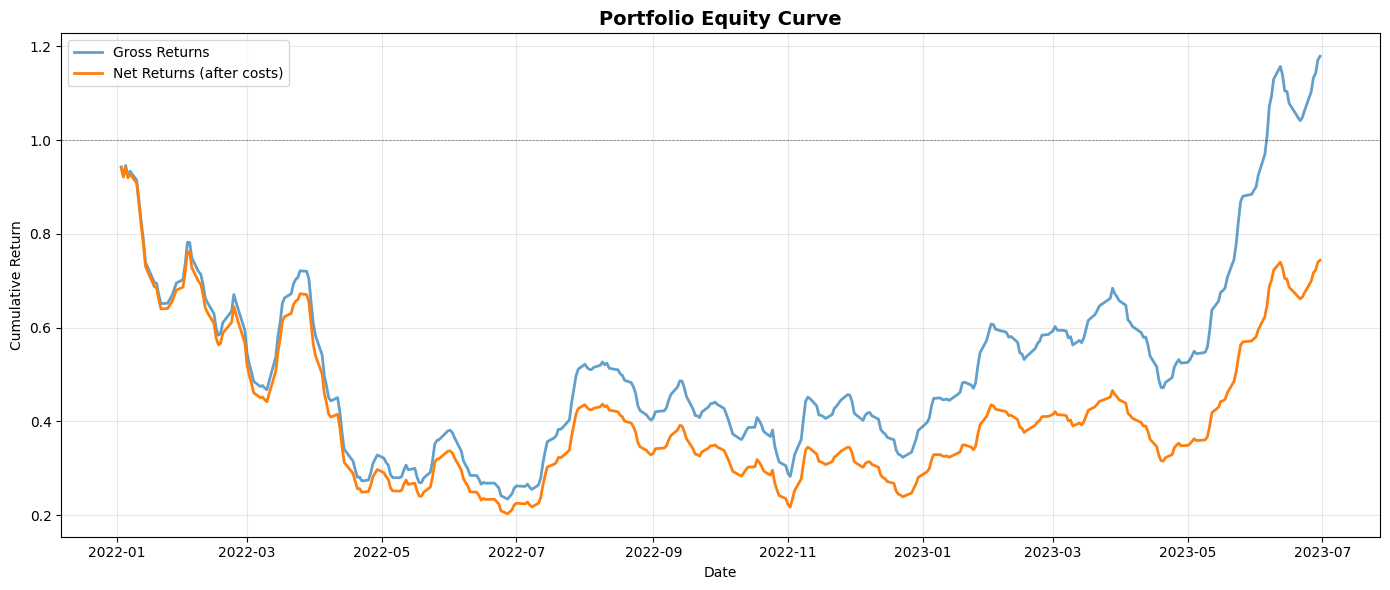

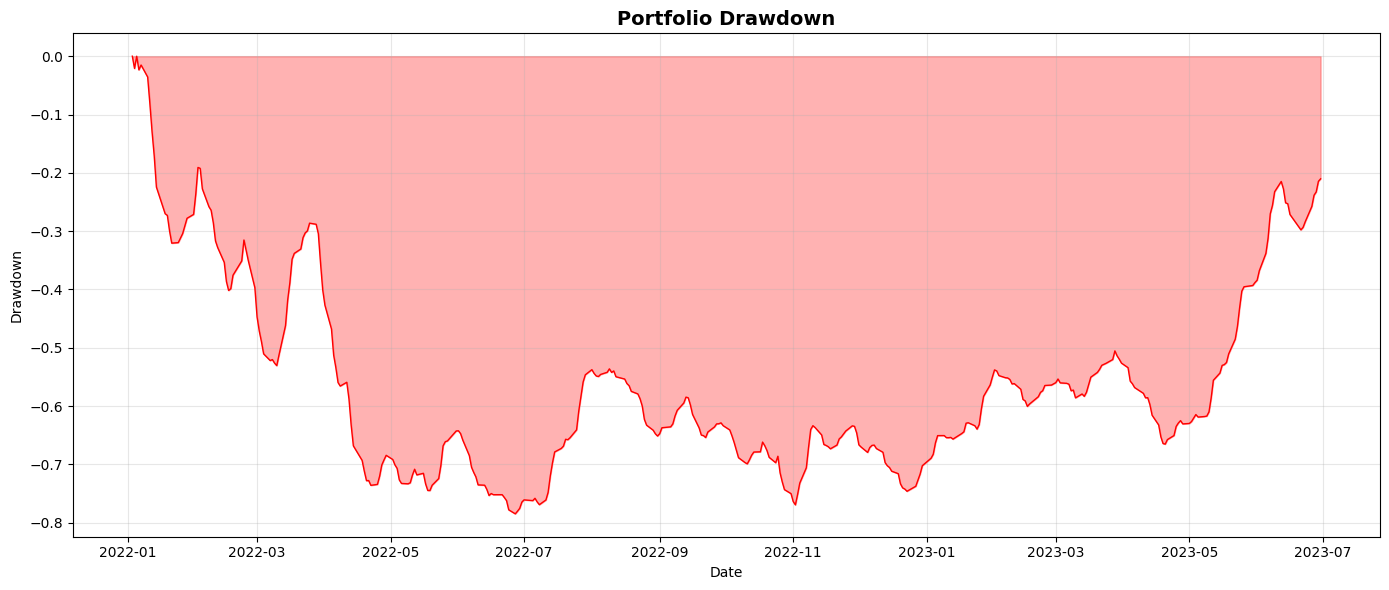

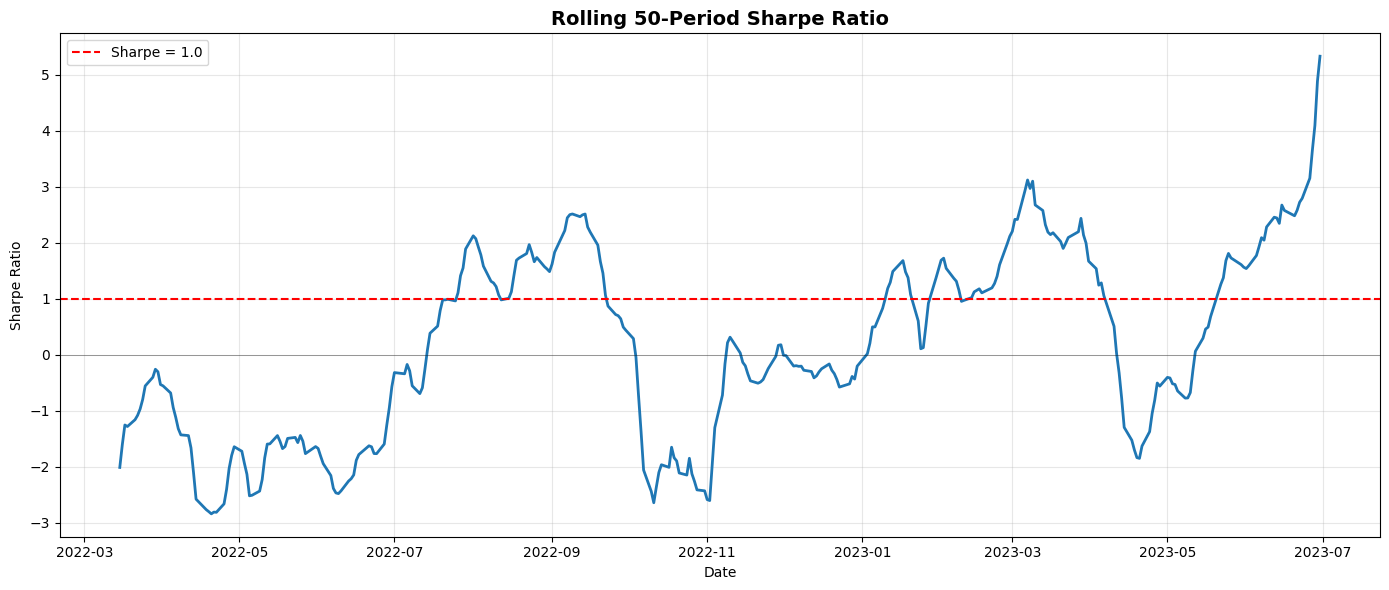

In [36]:
#First for simple baseline LR

def perf_pipeline(df):
    
    df = construct_portfolio(df, pred_col='pred', top_pct=0.2, bottom_pct=0.2)

    portfolio_returns = stock_pnl_and_returns(df)

    portfolio_returns = turnover(df, portfolio_returns)

    portfolio_returns = apply_transaction_costs(portfolio_returns)

    metrics = performance_metrics(portfolio_returns, return_col='net_return', freq=52)
    
    plots(portfolio_returns)
    
    return metrics
    
metrics = perf_pipeline(val1)

In [37]:
print(metrics)

{'total_return': np.float64(-0.2563131320613835), 'ann_return': np.float64(-0.005734635079735604), 'ann_vol': np.float64(0.2665365359025666), 'sharpe': np.float64(-0.021515380847569508), 'max_drawdown': np.float64(-0.7847197197524527), 'win_rate': np.float64(0.5013333333333333), 'avg_turnover': np.float64(1.2281481481481482), 'avg_cost': np.float64(0.0012281481481481481), 'n_periods': 375}


In [40]:
test1 = test_df.copy()

test1['pred'] = lr_model.predict(x_test)

Position sum check (should be ~0): 0.000000


/Users/sudhanvabharadwaj/Documents/Full_Quant_Pipeline/src/portfolio_cons_backtest.py:34: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.11111111 0.11111111 0.11111111 ... 0.11111111 0.11111111 0.11111111]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['position'] == 1, 'position'] = 1.0 / n_long[df['position'] == 1]


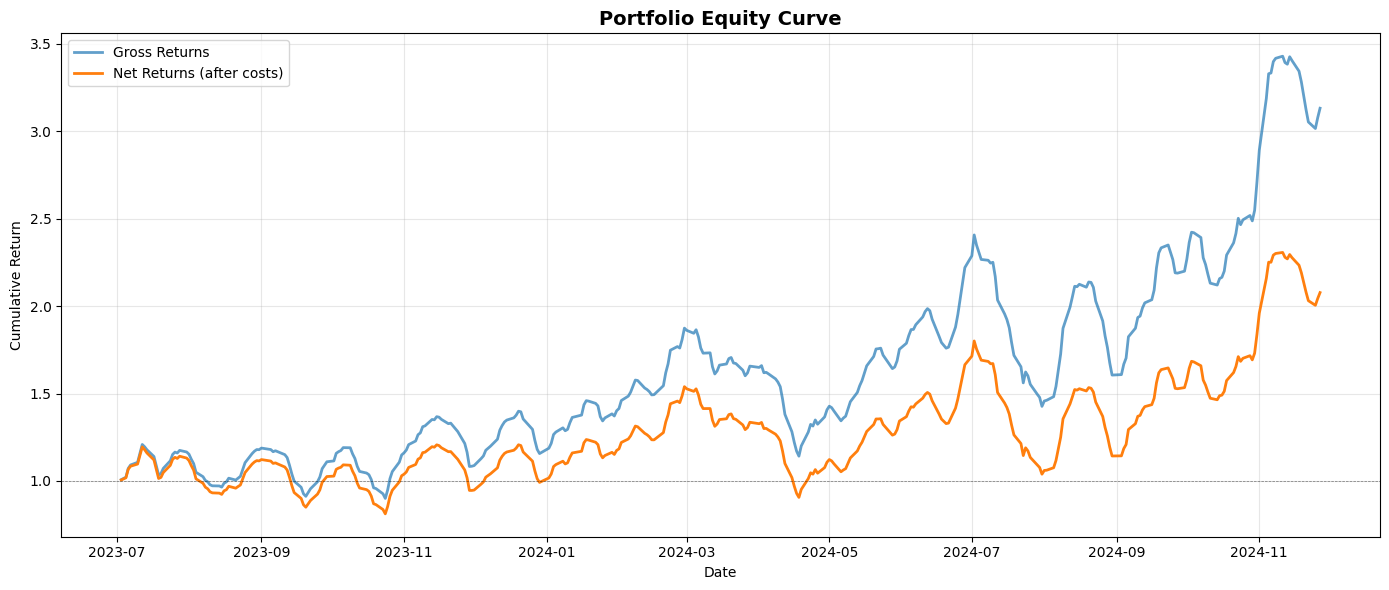

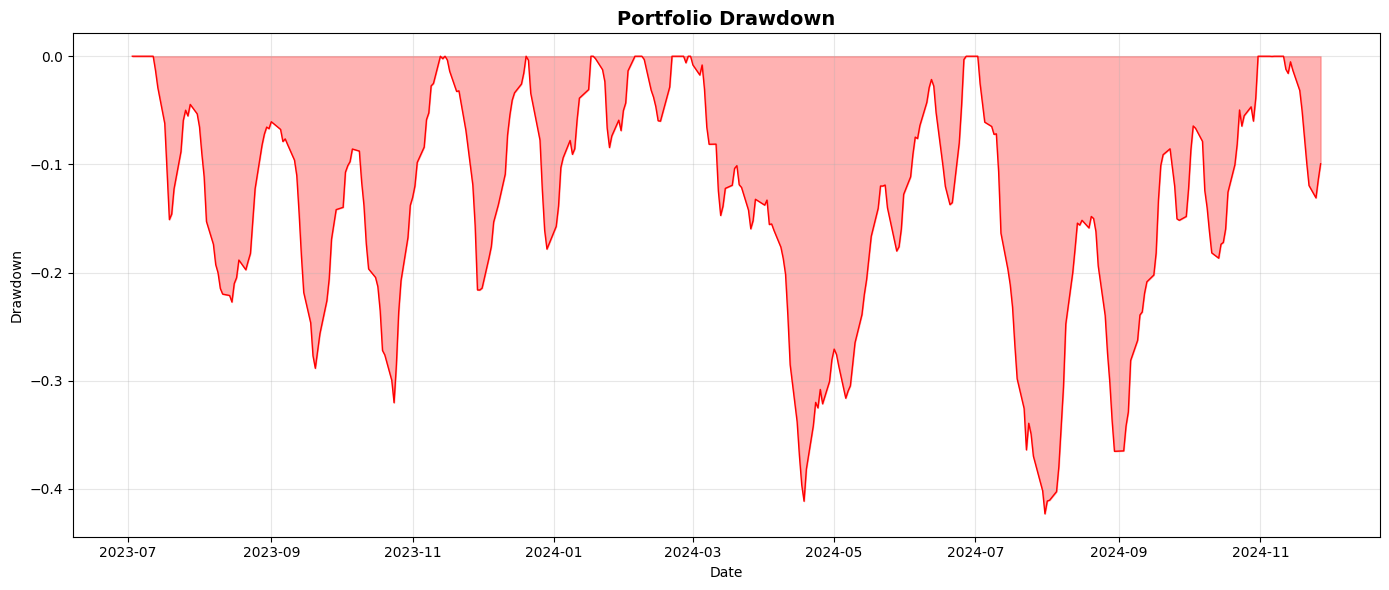

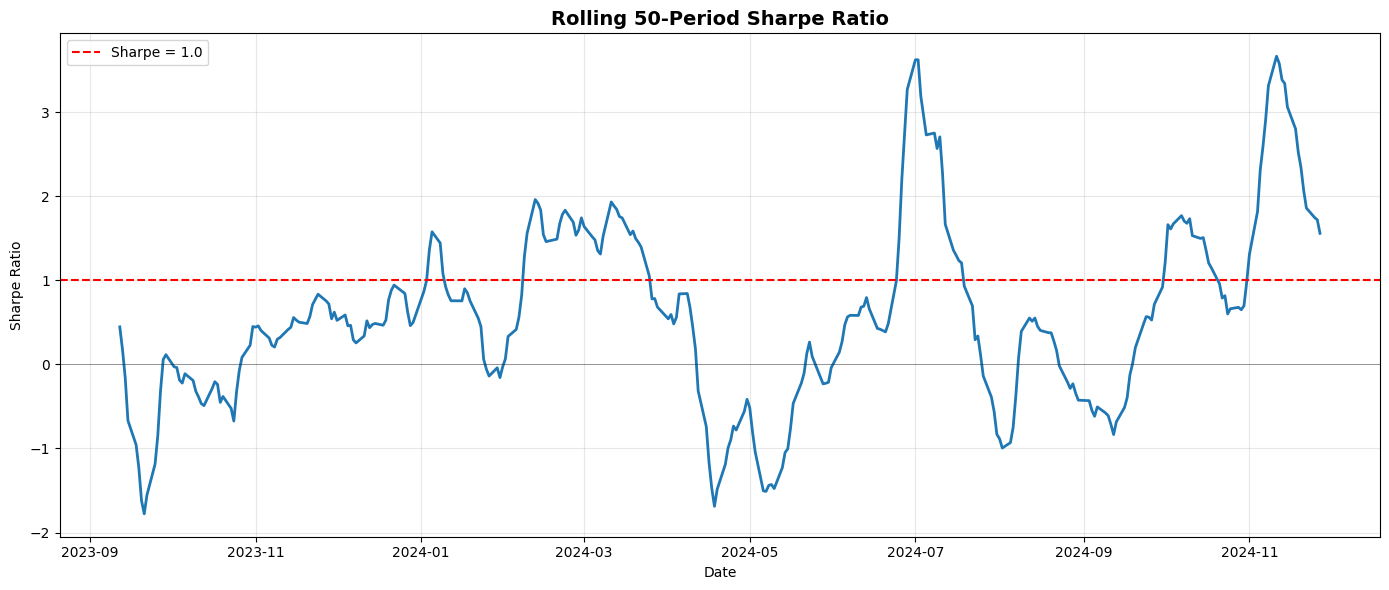

In [41]:
metrics = perf_pipeline(test1)

In [42]:
print(metrics)

{'total_return': np.float64(1.0772070330683996), 'ann_return': np.float64(0.12870646793572493), 'ann_vol': np.float64(0.20938910413128697), 'sharpe': np.float64(0.6146760523652939), 'max_drawdown': np.float64(-0.4231495440269801), 'win_rate': np.float64(0.547752808988764), 'avg_turnover': np.float64(1.1555087390761547), 'avg_cost': np.float64(0.0011555087390761546), 'n_periods': 356}


-------

2. Ridge Models

--------

In [43]:
val2 = val_df.copy()

val2['pred'] = ridge.predict(x_val)

test2 = test_df.copy()

test2['pred'] = ridge.predict(x_test)

Position sum check (should be ~0): 0.000000


/Users/sudhanvabharadwaj/Documents/Full_Quant_Pipeline/src/portfolio_cons_backtest.py:34: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.11111111 0.11111111 0.11111111 ... 0.11111111 0.11111111 0.11111111]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['position'] == 1, 'position'] = 1.0 / n_long[df['position'] == 1]


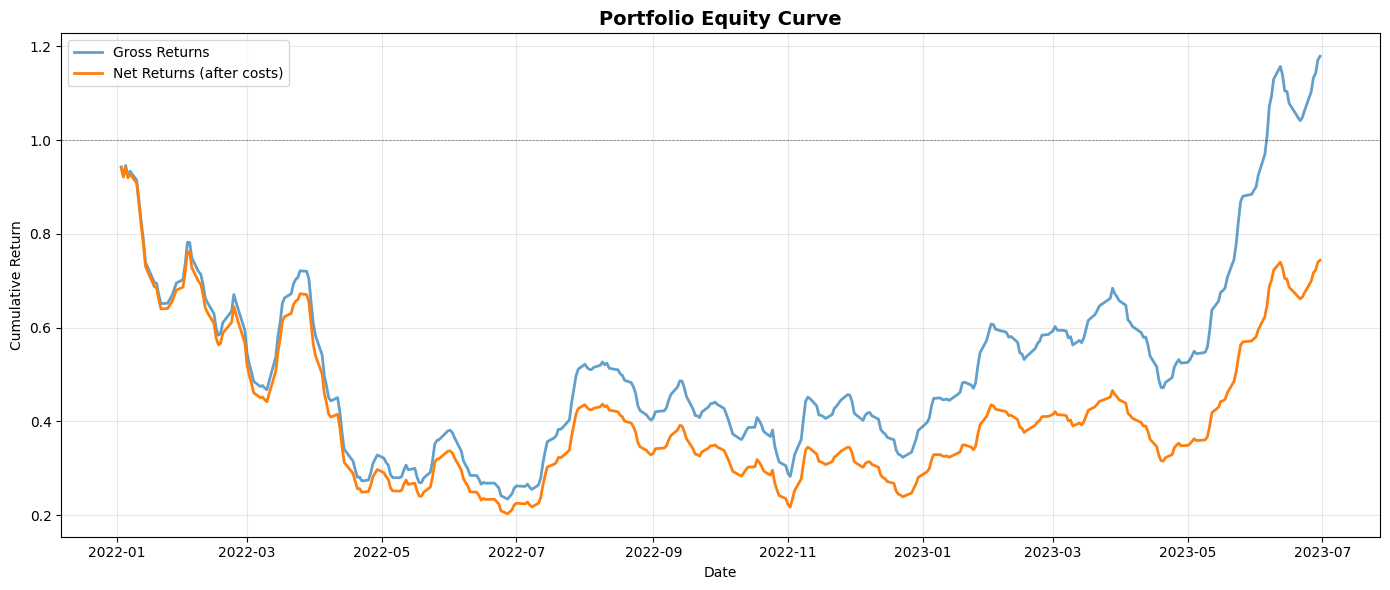

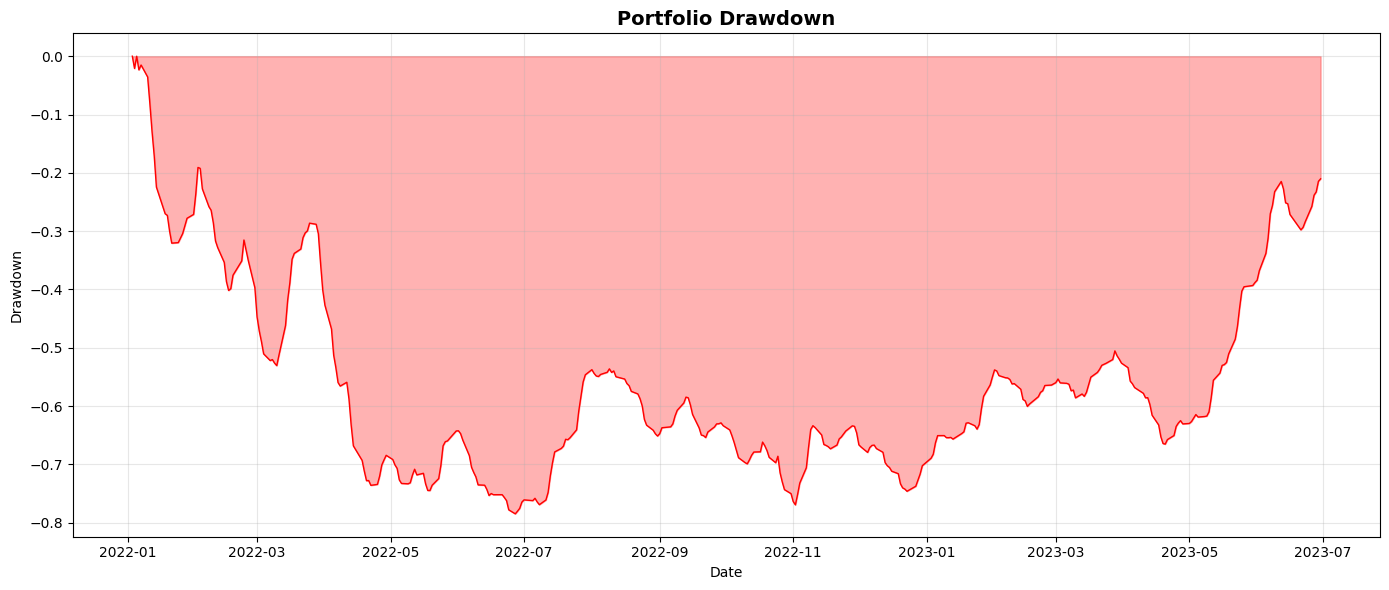

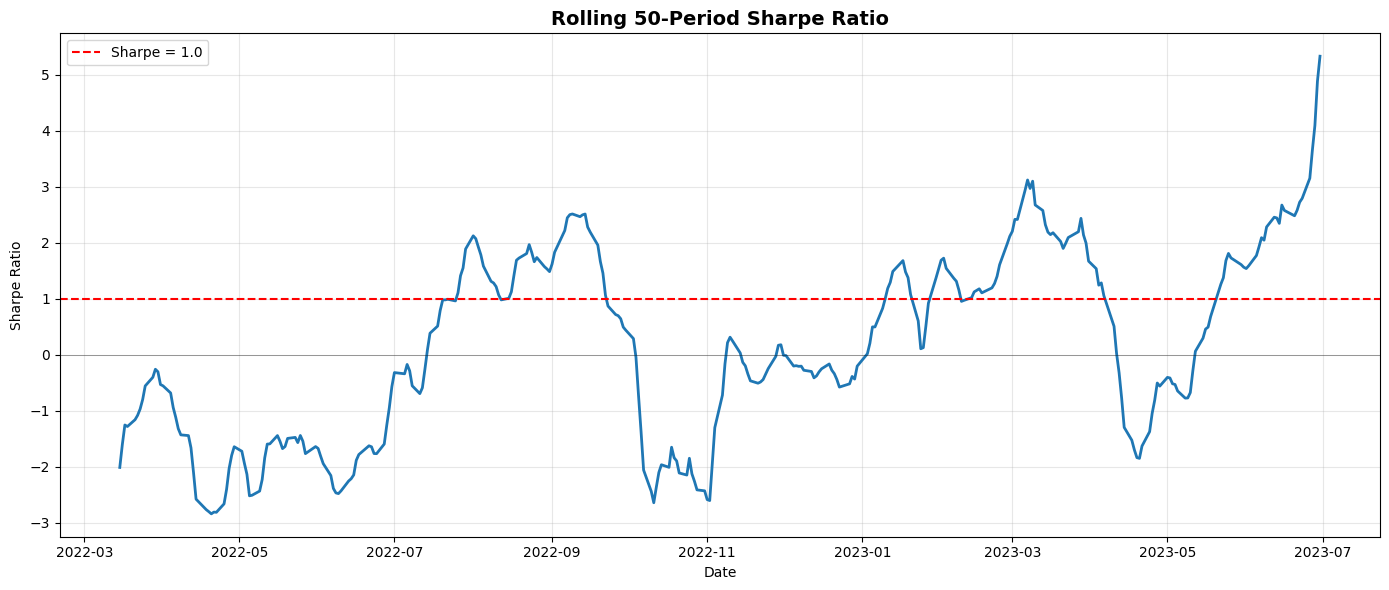

In [44]:
metrics = perf_pipeline(val2)

In [45]:
print(metrics)

{'total_return': np.float64(-0.2563131320613835), 'ann_return': np.float64(-0.005734635079735604), 'ann_vol': np.float64(0.2665365359025666), 'sharpe': np.float64(-0.021515380847569508), 'max_drawdown': np.float64(-0.7847197197524527), 'win_rate': np.float64(0.5013333333333333), 'avg_turnover': np.float64(1.2281481481481482), 'avg_cost': np.float64(0.0012281481481481481), 'n_periods': 375}


/Users/sudhanvabharadwaj/Documents/Full_Quant_Pipeline/src/portfolio_cons_backtest.py:34: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.11111111 0.11111111 0.11111111 ... 0.11111111 0.11111111 0.11111111]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['position'] == 1, 'position'] = 1.0 / n_long[df['position'] == 1]


Position sum check (should be ~0): 0.000000


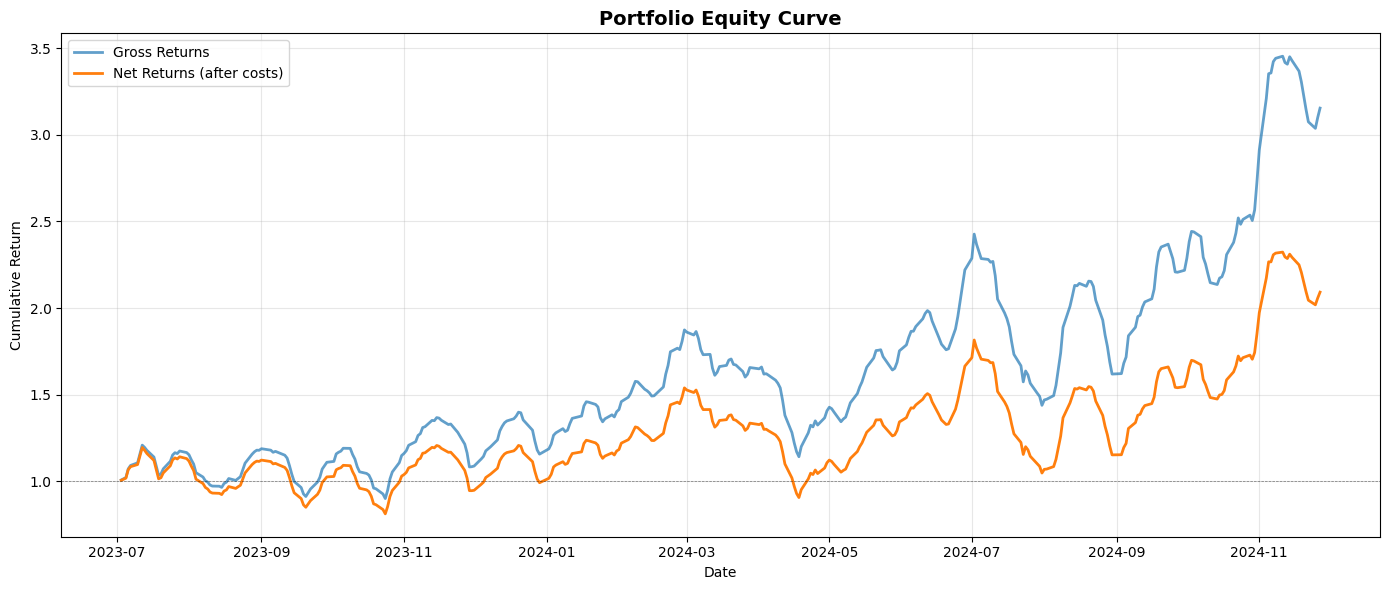

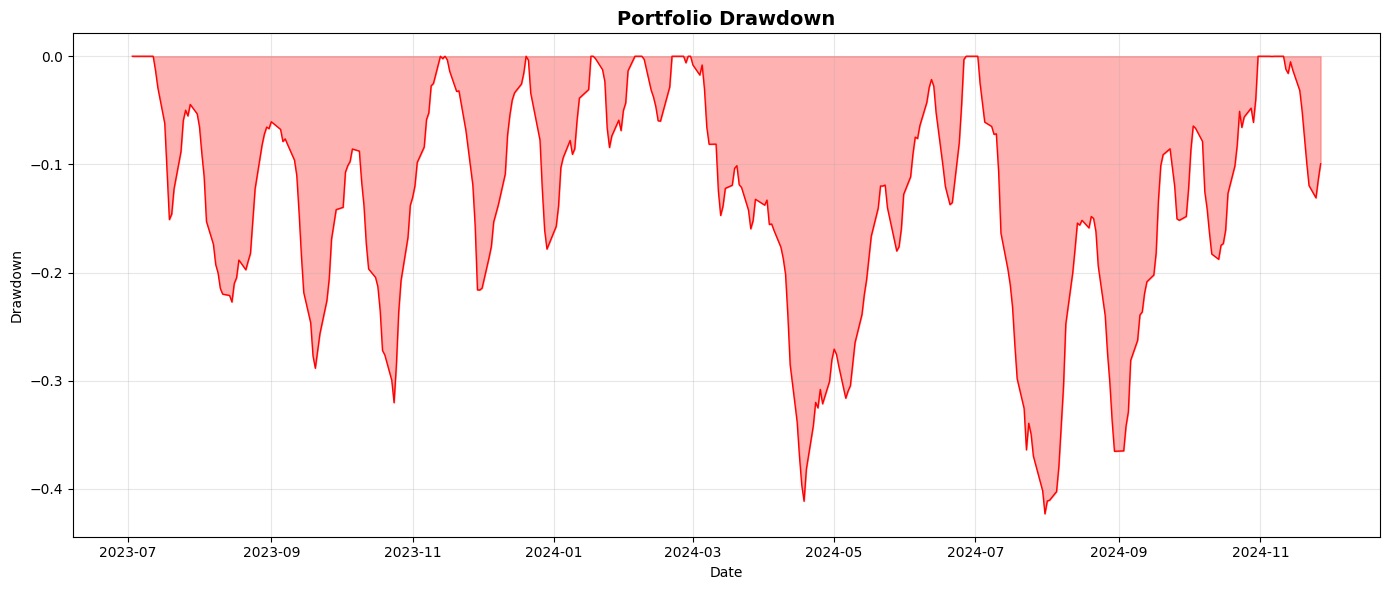

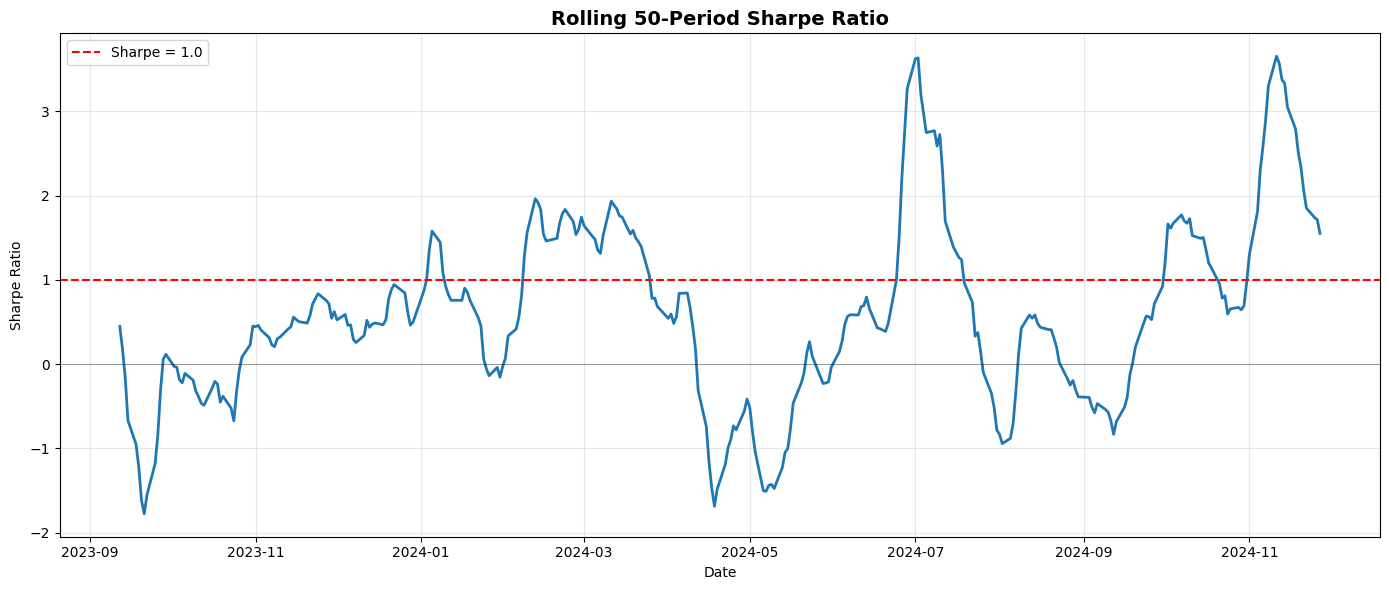

In [46]:
metrics = perf_pipeline(test2)

In [47]:
print(metrics)

{'total_return': np.float64(1.091992804314423), 'ann_return': np.float64(0.12981917303256602), 'ann_vol': np.float64(0.20975824616123762), 'sharpe': np.float64(0.6188990202214801), 'max_drawdown': np.float64(-0.42314954402698), 'win_rate': np.float64(0.547752808988764), 'avg_turnover': np.float64(1.156210986267166), 'avg_cost': np.float64(0.0011562109862671662), 'n_periods': 356}


# Ridge 2

In [48]:
val3 = val_df.copy()

val3['pred'] = ridge2.predict(x_val)

test3 = test_df.copy()

test3['pred'] = ridge2.predict(x_test)

Position sum check (should be ~0): 0.000000


/Users/sudhanvabharadwaj/Documents/Full_Quant_Pipeline/src/portfolio_cons_backtest.py:34: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.11111111 0.11111111 0.11111111 ... 0.11111111 0.11111111 0.11111111]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['position'] == 1, 'position'] = 1.0 / n_long[df['position'] == 1]


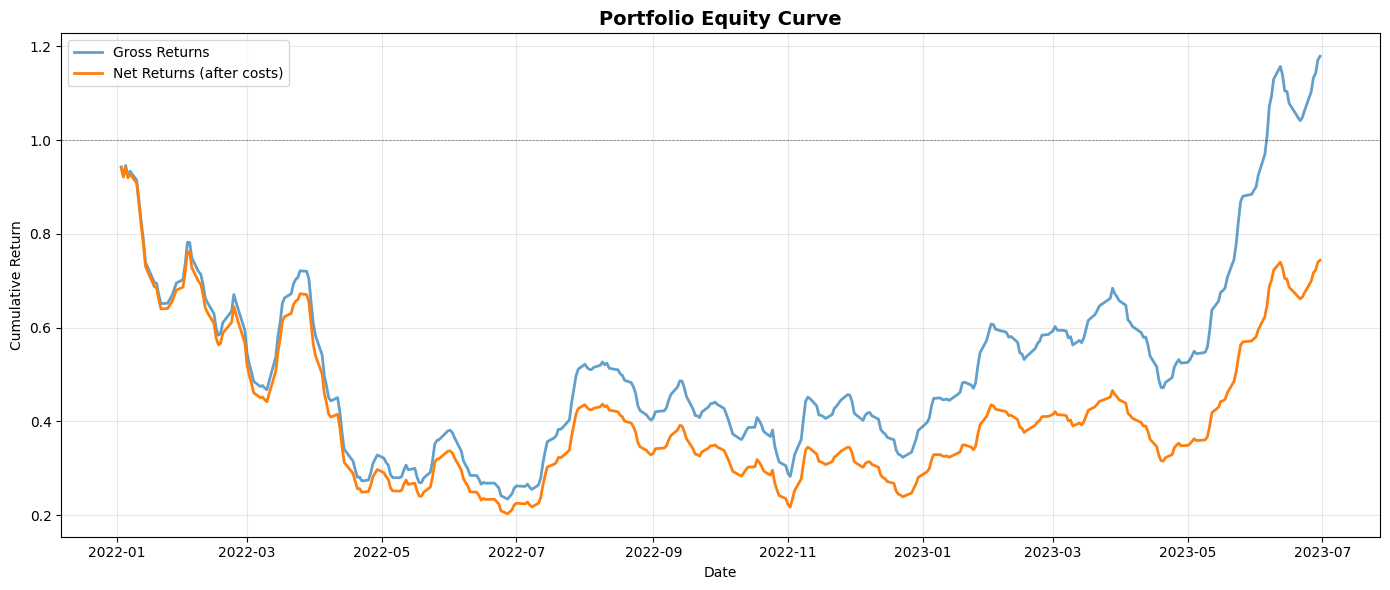

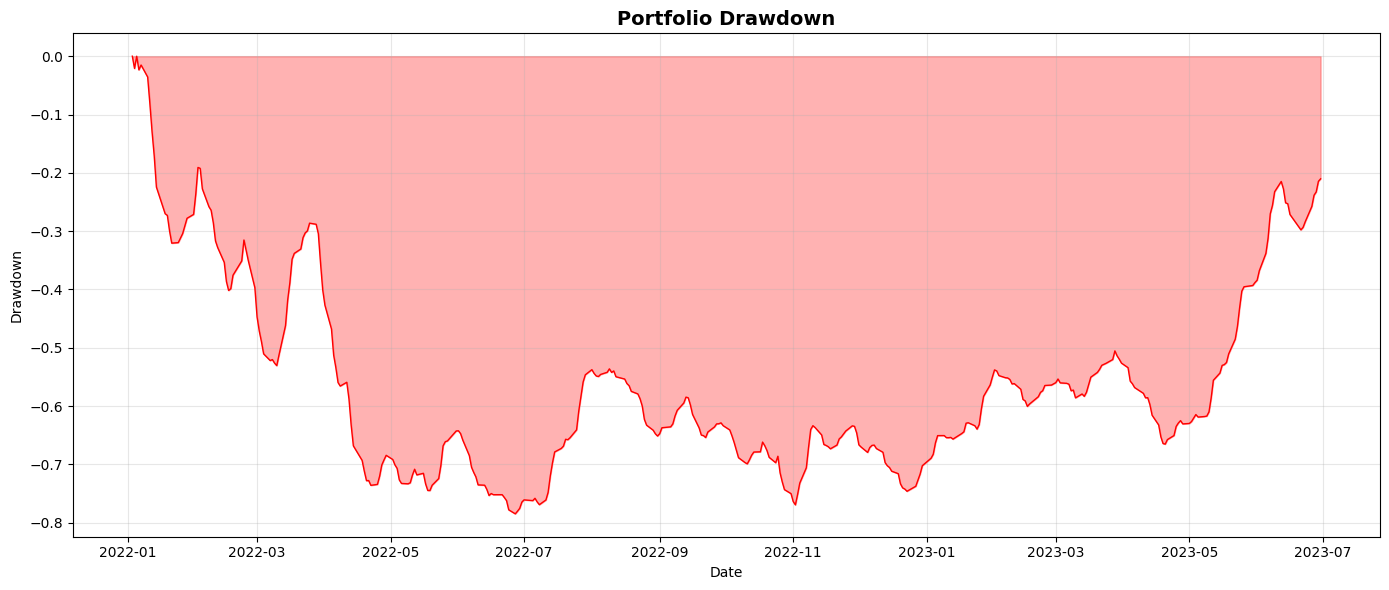

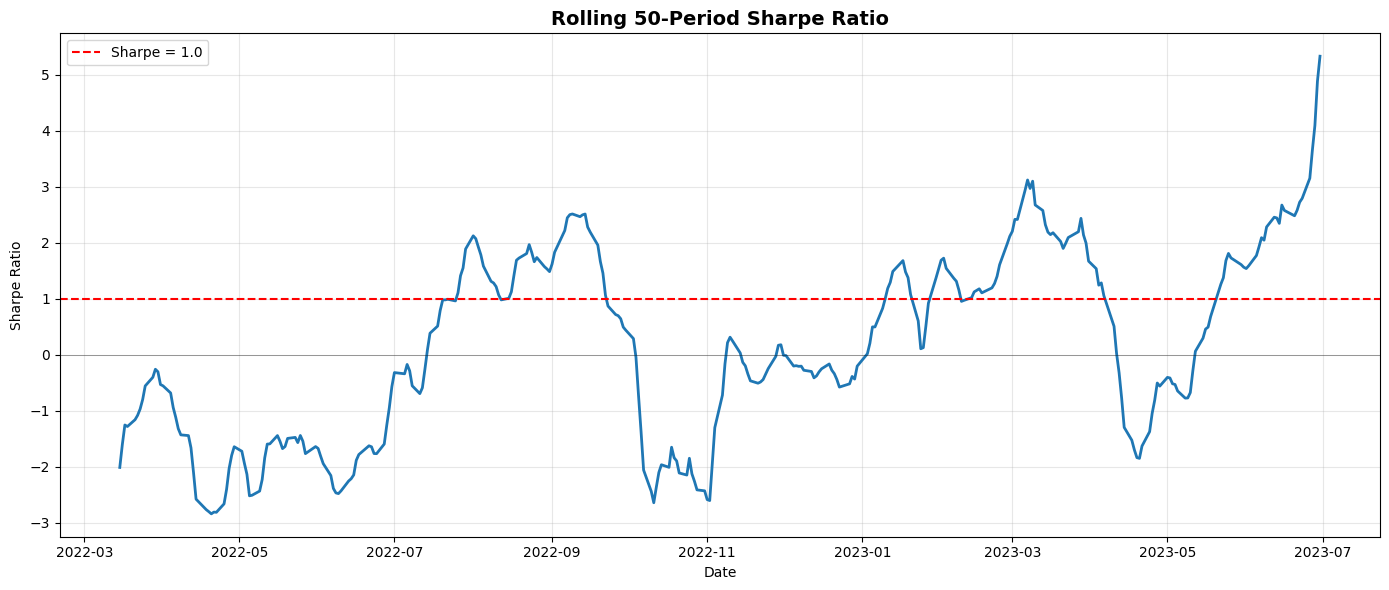

In [49]:
metrics = perf_pipeline(val3)

In [50]:
print(metrics)

{'total_return': np.float64(-0.2563131320613835), 'ann_return': np.float64(-0.005734635079735604), 'ann_vol': np.float64(0.2665365359025666), 'sharpe': np.float64(-0.021515380847569508), 'max_drawdown': np.float64(-0.7847197197524527), 'win_rate': np.float64(0.5013333333333333), 'avg_turnover': np.float64(1.2281481481481482), 'avg_cost': np.float64(0.0012281481481481481), 'n_periods': 375}


Position sum check (should be ~0): 0.000000


/Users/sudhanvabharadwaj/Documents/Full_Quant_Pipeline/src/portfolio_cons_backtest.py:34: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.11111111 0.11111111 0.11111111 ... 0.11111111 0.11111111 0.11111111]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['position'] == 1, 'position'] = 1.0 / n_long[df['position'] == 1]


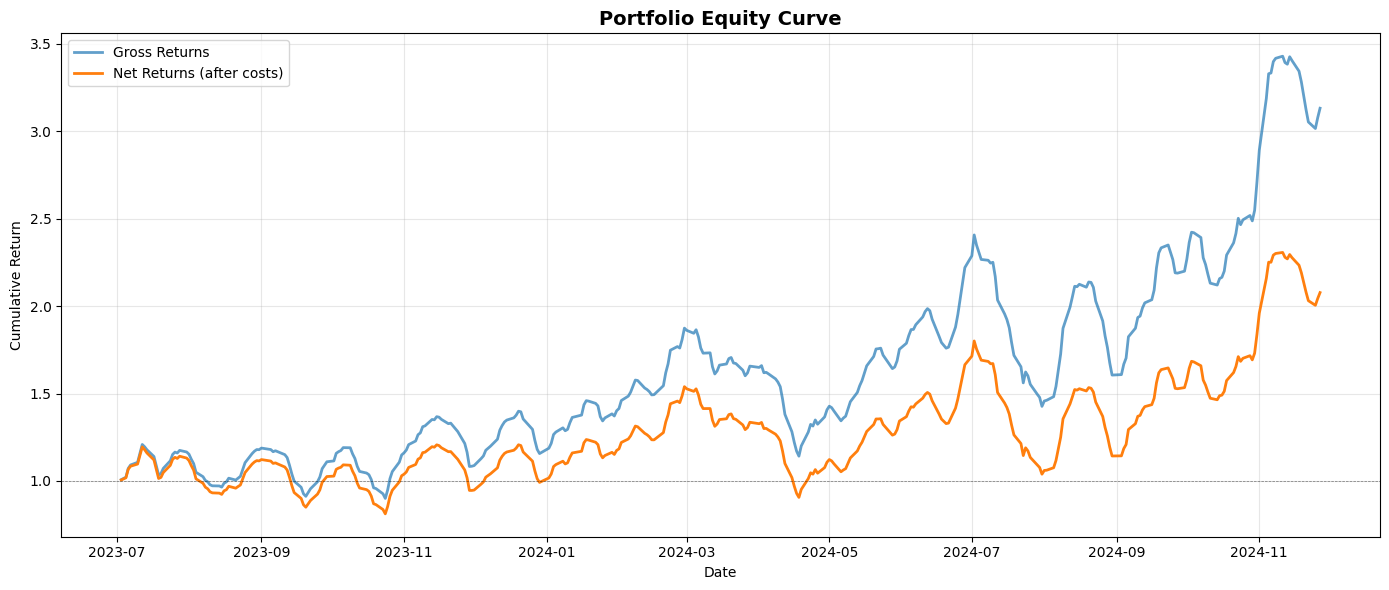

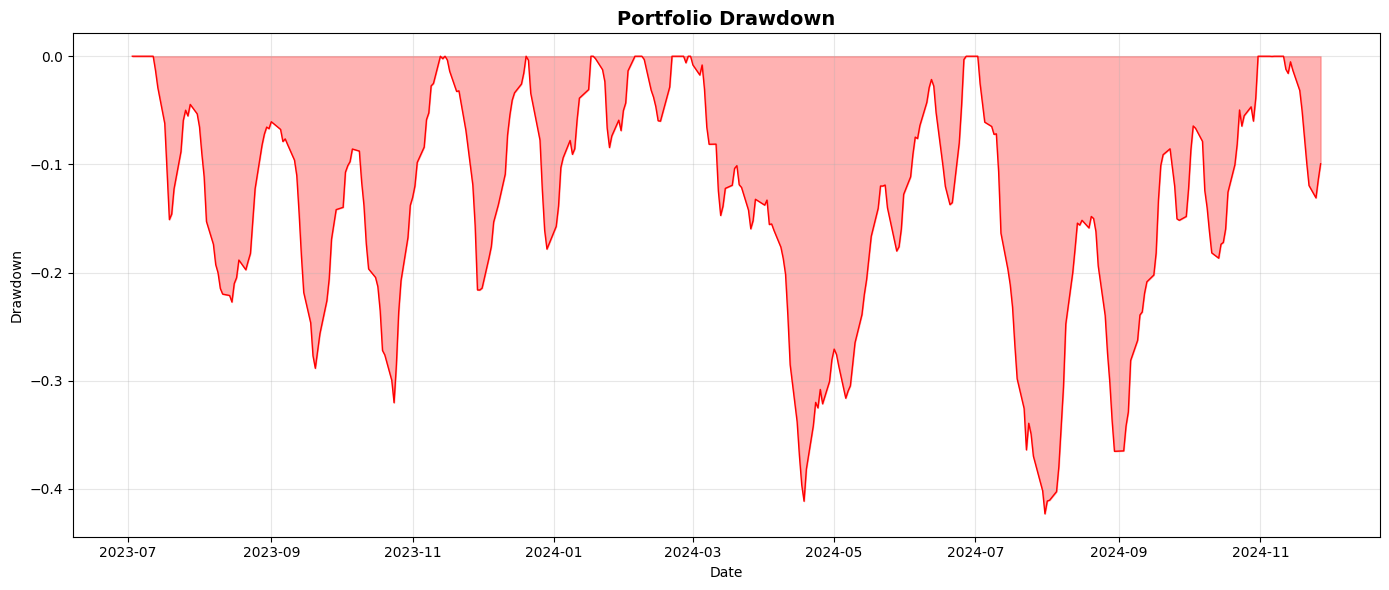

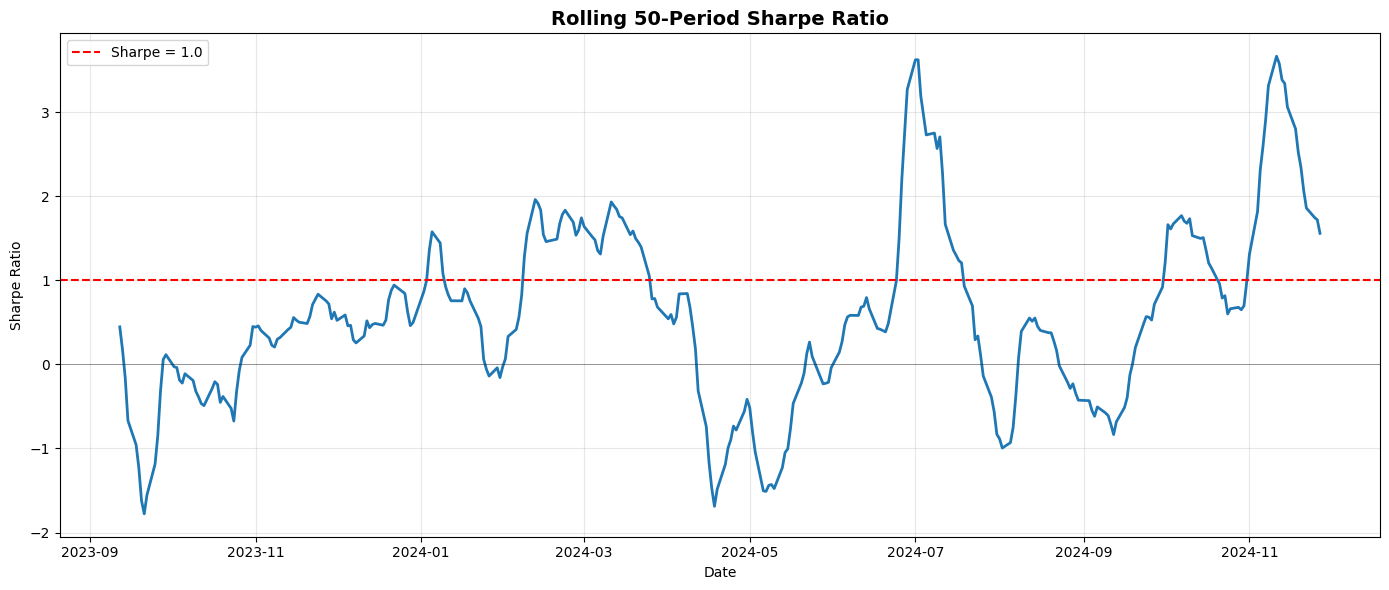

In [51]:
metrics = perf_pipeline(test3)

In [52]:
print(metrics)

{'total_return': np.float64(1.0772070330683996), 'ann_return': np.float64(0.12870646793572493), 'ann_vol': np.float64(0.20938910413128697), 'sharpe': np.float64(0.6146760523652939), 'max_drawdown': np.float64(-0.4231495440269801), 'win_rate': np.float64(0.547752808988764), 'avg_turnover': np.float64(1.1555087390761547), 'avg_cost': np.float64(0.0011555087390761546), 'n_periods': 356}


------